In [2]:
# 03 - Exploratory Data Analysis (EDA)
# Answers, one chart each: Who uses AI? Which tools are most used? Age vs AI
# usage, Occupation vs AI usage, Residence vs AI usage, Purpose vs tool,
# Concerns vs tool, Satisfaction vs tool, Switching reasons.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('data/processed/AI_Tool_Survey_Cleaned.csv')
users = df[df['Is_AI_User']].copy()
order_age = ['13 - 17', '18 - 24', '25 - 34', '35 - 44', '45 and above']
print(f"Total respondents: {len(df)} | AI users: {len(users)} | Non-users: {len(df) - len(users)}")


Total respondents: 200 | AI users: 195 | Non-users: 5


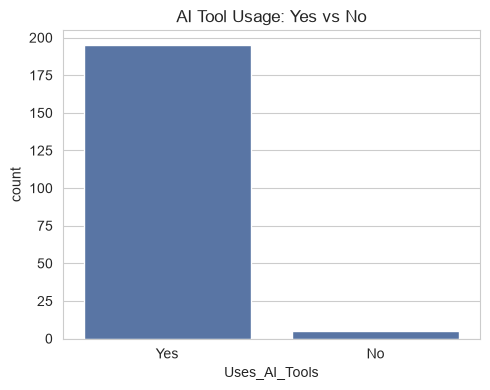

Uses_AI_Tools
Yes    97.5
No      2.5
Name: proportion, dtype: float64 %


In [3]:
# Who uses AI? 
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Uses_AI_Tools', color='#4C72B0')
plt.title('AI Tool Usage: Yes vs No')
plt.tight_layout()
plt.show()
print(df['Uses_AI_Tools'].value_counts(normalize=True).round(3) * 100, "%")


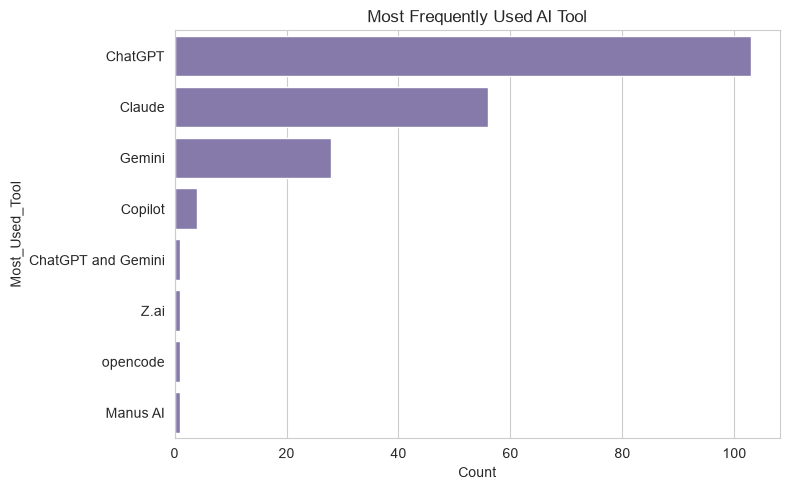

In [4]:
# Which tools are most used? 
plt.figure(figsize=(8, 5))
order = users['Most_Used_Tool'].value_counts().index
sns.countplot(data=users, y='Most_Used_Tool', order=order, color='#8172B2')
plt.title('Most Frequently Used AI Tool')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


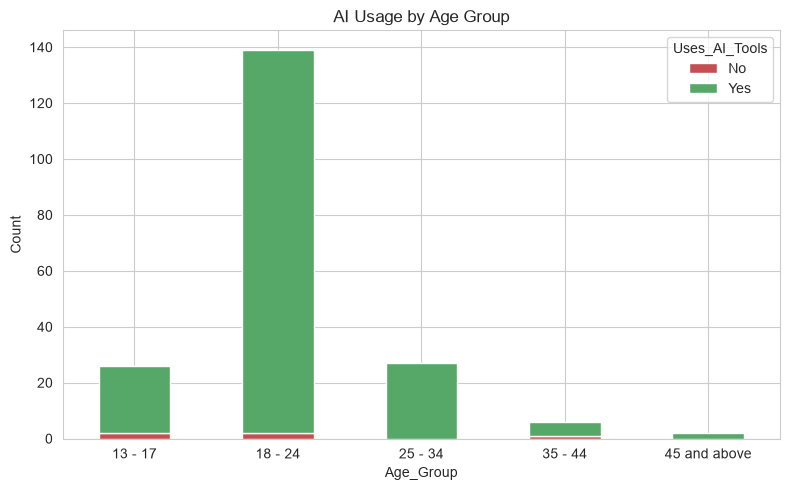

Uses_AI_Tools,No,Yes
Age_Group,,
13 - 17,2,24
18 - 24,2,137
25 - 34,0,27
35 - 44,1,5
45 and above,0,2


In [5]:
# Age vs AI usage 
ct = pd.crosstab(df['Age_Group'], df['Uses_AI_Tools'])
ct = ct.reindex([a for a in order_age if a in ct.index])
ct.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#C44E52', '#55A868'])
plt.title('AI Usage by Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
ct


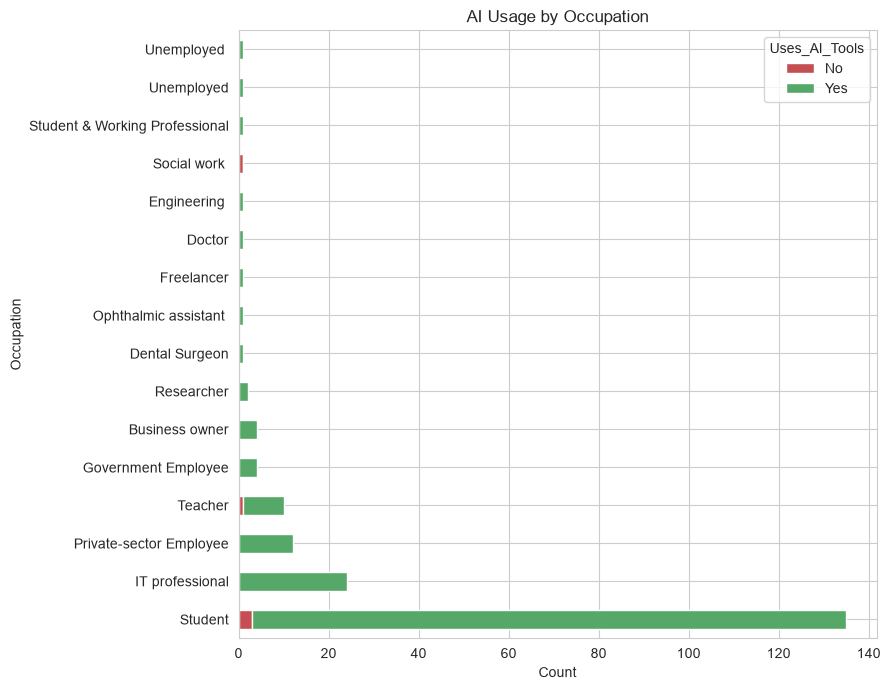

In [6]:
# Occupation vs AI usage 
ct_occ = pd.crosstab(df['Occupation'], df['Uses_AI_Tools'])
ct_occ = ct_occ.loc[ct_occ.sum(axis=1).sort_values(ascending=False).index]
ct_occ.plot(kind='barh', stacked=True, figsize=(9, 7), color=['#C44E52', '#55A868'])
plt.title('AI Usage by Occupation')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


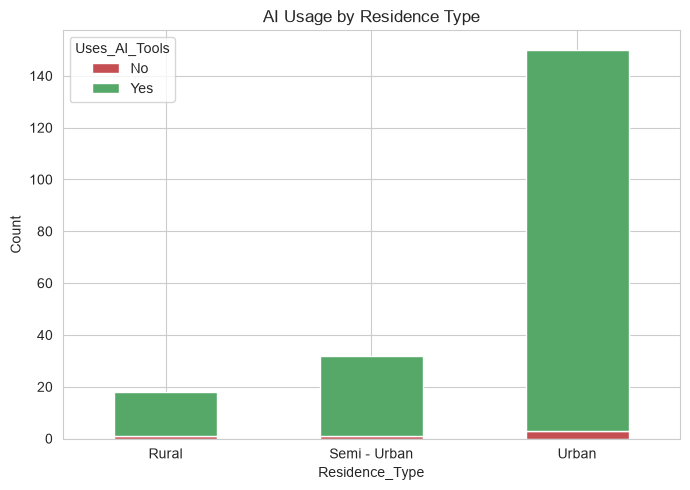

Uses_AI_Tools,No,Yes
Residence_Type,,
Rural,1,17
Semi - Urban,1,31
Urban,3,147


In [7]:
# Residence vs AI usage 
ct_res = pd.crosstab(df['Residence_Type'], df['Uses_AI_Tools'])
ct_res.plot(kind='bar', stacked=True, figsize=(7, 5), color=['#C44E52', '#55A868'])
plt.title('AI Usage by Residence Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
ct_res


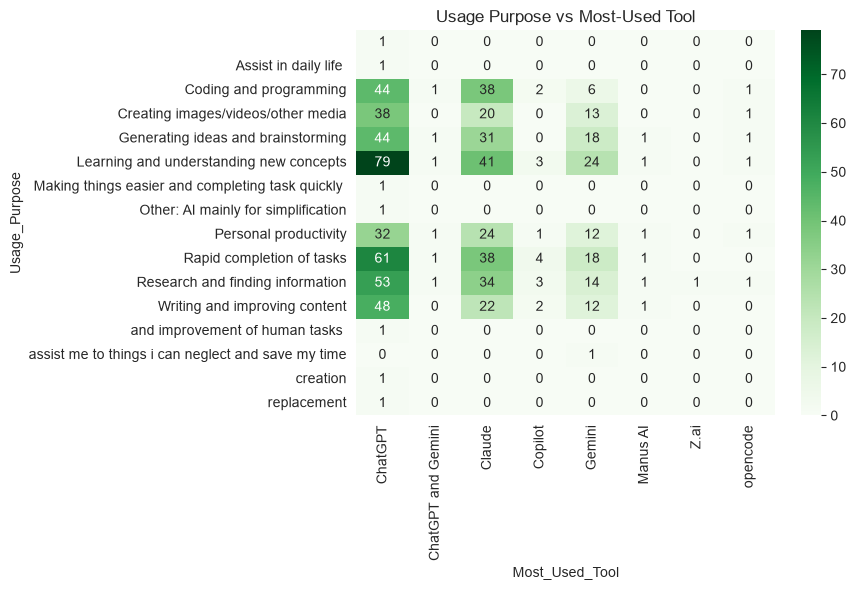

In [8]:
# Purpose vs tool 
purpose_exp = users[['Most_Used_Tool', 'Usage_Purpose']].dropna().reset_index(drop=True)
purpose_exp['Usage_Purpose'] = purpose_exp['Usage_Purpose'].str.split('; ')
purpose_exp = purpose_exp.explode('Usage_Purpose').reset_index(drop=True)
pivot = pd.crosstab(purpose_exp['Usage_Purpose'], purpose_exp['Most_Used_Tool'])
plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Greens')
plt.title('Usage Purpose vs Most-Used Tool')
plt.tight_layout()
plt.show()


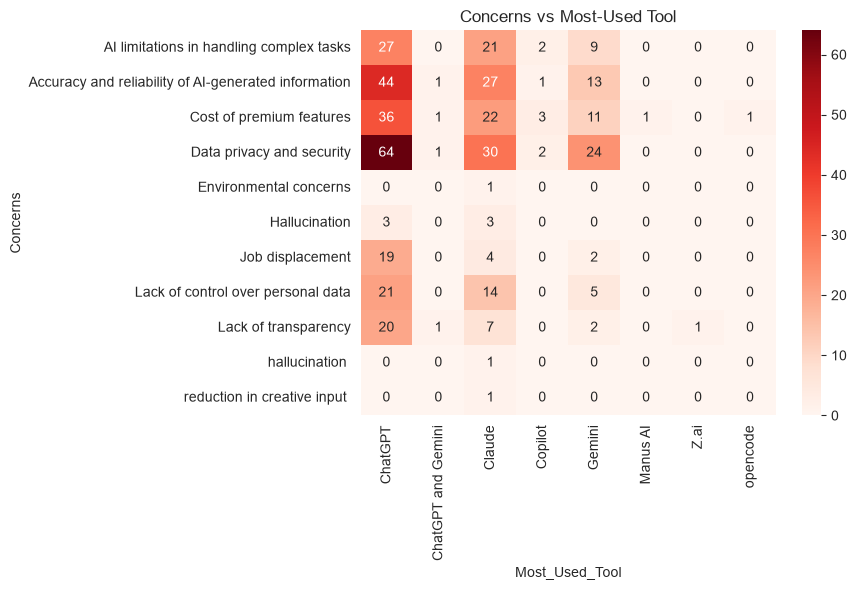

In [9]:
# Concerns vs tool 
concern_exp = users[['Most_Used_Tool', 'Concerns']].dropna().reset_index(drop=True)
concern_exp['Concerns'] = concern_exp['Concerns'].str.split('; ')
concern_exp = concern_exp.explode('Concerns').reset_index(drop=True)
pivot_c = pd.crosstab(concern_exp['Concerns'], concern_exp['Most_Used_Tool'])
plt.figure(figsize=(9, 6))
sns.heatmap(pivot_c, annot=True, fmt='d', cmap='Reds')
plt.title('Concerns vs Most-Used Tool')
plt.tight_layout()
plt.show()


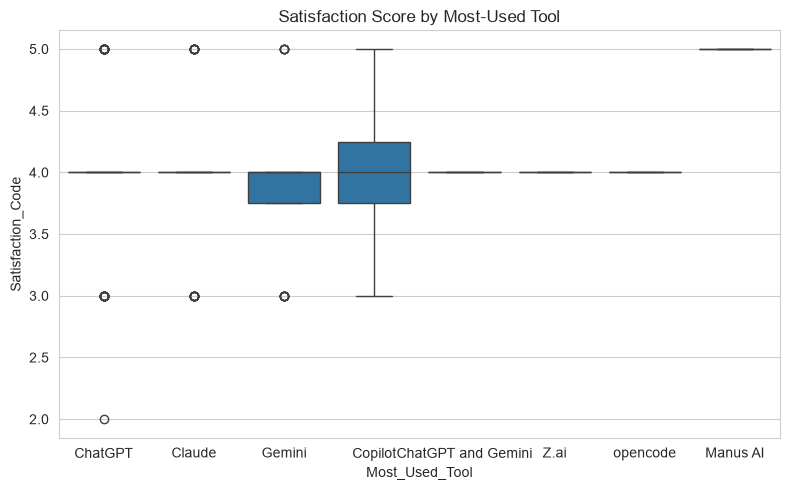

Most_Used_Tool
Manus AI              5.00
ChatGPT and Gemini    4.00
Z.ai                  4.00
Copilot               4.00
opencode              4.00
ChatGPT               3.96
Claude                3.96
Gemini                3.89
Name: Satisfaction_Code, dtype: float64


In [10]:
# Satisfaction vs tool 
plt.figure(figsize=(8, 5))
sns.boxplot(data=users, x='Most_Used_Tool', y='Satisfaction_Code',
            order=users['Most_Used_Tool'].value_counts().index)
plt.title('Satisfaction Score by Most-Used Tool')
plt.tight_layout()
plt.show()
print(users.groupby('Most_Used_Tool')['Satisfaction_Code'].mean().round(2).sort_values(ascending=False))


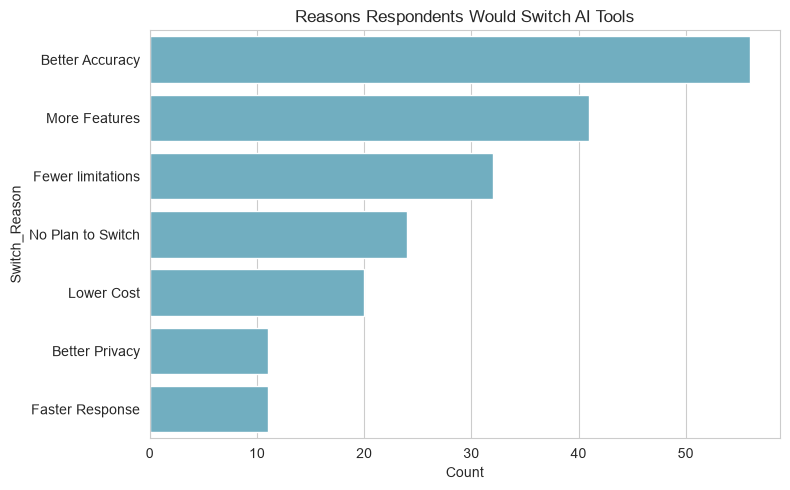

In [11]:
# Switching reasons 
plt.figure(figsize=(8, 5))
sw = users['Switch_Reason'].dropna()
sns.countplot(y=sw, order=sw.value_counts().index, color='#64B5CD')
plt.title('Reasons Respondents Would Switch AI Tools')
plt.xlabel('Count')
plt.tight_layout()
plt.show()
